# Complete Analysis: Teen Mental Health & Social Media

This notebook provides a comprehensive analysis of the relationship between social media usage and mental health indicators in teenagers.

## Contents
1. Data Loading & Overview
2. Descriptive Statistics
3. Correlation Analysis
4. Visualizations
5. Statistical Tests
6. Key Insights

In [4]:
!pip install pandas matplotlib seaborn scikit-learn numpy scipy 

In [6]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
try:
    from scipy import stats
except ModuleNotFoundError:
    import sys
    import subprocess

    subprocess.check_call([sys.executable, "-m", "pip", "install", "scipy"])
    from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Libraries imported successfully")

  Using cached scipy-1.15.3-cp310-cp310-macosx_14_0_arm64.whl.metadata (61 kB)
Using cached scipy-1.15.3-cp310-cp310-macosx_14_0_arm64.whl (22.4 MB)



[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: /opt/homebrew/opt/python@3.10/bin/python3.10 -m pip install --upgrade pip


✓ Libraries imported successfully


## 1. Data Loading & Overview

In [7]:
# Load the cleaned dataset
df = pd.read_csv("../data/processed/cleaned_data.csv")

print(f"Dataset Shape: {df.shape}")
print(f"\nColumns ({len(df.columns)}):")
print(df.columns.tolist())

Dataset Shape: (1200, 17)

Columns (17):
['age', 'gender', 'daily_social_media_hours', 'platform_usage', 'sleep_hours', 'screen_time_before_sleep', 'academic_performance', 'physical_activity', 'social_interaction_level', 'stress_level', 'anxiety_level', 'addiction_level', 'social_interaction_score', 'mental_health_score', 'high_social_media_usage', 'low_sleep', 'late_night_screen']


In [8]:
# Preview the data
df.head(10)

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,social_interaction_score,mental_health_score,high_social_media_usage,low_sleep,late_night_screen
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,1,4,1,0,1
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,3,9,0,0,1
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,3,6,0,0,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,2,8,1,0,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,2,8,1,1,1
5,19,female,7.4,Both,4.4,2.4,2.63,0.6,high,3,5,7,3,8,1,1,1
6,18,female,2.5,Instagram,6.4,2.4,2.63,0.7,low,2,2,5,1,4,0,0,1
7,16,male,4.0,Both,4.2,0.5,2.40,1.3,low,6,10,5,1,16,0,1,0
8,19,female,3.3,TikTok,5.0,2.1,2.04,0.9,high,1,10,9,3,11,0,1,1
9,15,male,1.9,TikTok,4.9,1.5,3.77,1.1,high,1,1,4,3,2,0,1,0


In [9]:
# Data types and info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   object 
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   object 
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   object 
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  social_interaction_score  1200 non-null   int64  
 13  mental_health_score       1200 non-null   int64  
 14  high_soc

## 2. Descriptive Statistics

In [10]:
# Summary statistics for numeric variables
df.describe().round(2)

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,social_interaction_score,mental_health_score,high_social_media_usage,low_sleep,late_night_screen
count,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00
mean,15.93,4.54,6.45,1.74,2.99,1.01,5.45,5.64,5.56,1.96,11.08,0.56,0.40,0.37
std,2.02,2.03,1.44,0.72,0.58,0.58,2.90,2.86,2.83,0.81,4.11,0.50,0.49,0.48
min,13.00,1.00,4.00,0.50,2.00,0.00,1.00,1.00,1.00,1.00,2.00,0.00,0.00,0.00
25%,14.00,2.80,5.20,1.10,2.50,0.50,3.00,3.00,3.00,1.00,8.00,0.00,0.00,0.00
50%,16.00,4.50,6.50,1.80,2.99,1.00,5.00,6.00,6.00,2.00,11.00,1.00,0.00,0.00
75%,18.00,6.30,7.60,2.40,3.48,1.50,8.00,8.00,8.00,3.00,14.00,1.00,1.00,1.00
max,19.00,8.00,9.00,3.00,4.00,2.00,10.00,10.00,10.00,3.00,20.00,1.00,1.00,1.00


In [11]:
# Categorical variables distribution
print("Gender Distribution:")
print(df['gender'].value_counts())
print(f"\nPlatform Usage:")
print(df['platform_usage'].value_counts())
print(f"\nSocial Interaction Level:")
print(df['social_interaction_level'].value_counts())

Gender Distribution:
gender
male      615
female    585
Name: count, dtype: int64

Platform Usage:
platform_usage
Instagram    411
TikTok       398
Both         391
Name: count, dtype: int64

Social Interaction Level:
social_interaction_level
medium    416
low       415
high      369
Name: count, dtype: int64


In [12]:
# Risk flags summary
print("Risk Flags Summary:")
print(f"High Social Media Usage (>4 hrs/day): {df['high_social_media_usage'].sum()} ({df['high_social_media_usage'].mean()*100:.1f}%)")
print(f"Low Sleep (<6 hrs/night): {df['low_sleep'].sum()} ({df['low_sleep'].mean()*100:.1f}%)")
print(f"Late Night Screen (>2 hrs before bed): {df['late_night_screen'].sum()} ({df['late_night_screen'].mean()*100:.1f}%)")

Risk Flags Summary:
High Social Media Usage (>4 hrs/day): 672 (56.0%)
Low Sleep (<6 hrs/night): 480 (40.0%)
Late Night Screen (>2 hrs before bed): 442 (36.8%)


## 3. Correlation Analysis

In [13]:
# Select numeric columns for correlation
numeric_cols = ['age', 'daily_social_media_hours', 'sleep_hours', 
                'screen_time_before_sleep', 'academic_performance', 
                'physical_activity', 'stress_level', 'anxiety_level', 
                'addiction_level', 'mental_health_score']

correlation_matrix = df[numeric_cols].corr()
correlation_matrix.round(3)

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,mental_health_score
age,1.000,-0.007,0.002,0.076,-0.014,0.011,-0.031,0.026,0.038,-0.004
daily_social_media_hours,-0.007,1.000,-0.009,0.036,0.013,0.026,0.031,0.028,-0.025,0.041
sleep_hours,0.002,-0.009,1.000,0.010,0.022,0.013,-0.011,-0.012,-0.055,-0.016
screen_time_before_sleep,0.076,0.036,0.010,1.000,-0.035,-0.026,-0.009,-0.010,0.029,-0.013
academic_performance,-0.014,0.013,0.022,-0.035,1.000,0.023,-0.001,-0.064,0.029,-0.045
physical_activity,0.011,0.026,0.013,-0.026,0.023,1.000,0.012,-0.022,0.026,-0.007
stress_level,-0.031,0.031,-0.011,-0.009,-0.001,0.012,1.000,0.016,-0.000,0.718
anxiety_level,0.026,0.028,-0.012,-0.010,-0.064,-0.022,0.016,1.000,0.031,0.707
addiction_level,0.038,-0.025,-0.055,0.029,0.029,0.026,-0.000,0.031,1.000,0.022
mental_health_score,-0.004,0.041,-0.016,-0.013,-0.045,-0.007,0.718,0.707,0.022,1.000


In [14]:
# Top correlations with mental health score
print("Correlations with Mental Health Score:")
mental_health_corr = correlation_matrix['mental_health_score'].sort_values(ascending=False)
print(mental_health_corr)

Correlations with Mental Health Score:
mental_health_score         1.000000
stress_level                0.717907
anxiety_level               0.707403
daily_social_media_hours    0.041079
addiction_level             0.021599
age                        -0.003706
physical_activity          -0.006884
screen_time_before_sleep   -0.013316
sleep_hours                -0.016031
academic_performance       -0.045246
Name: mental_health_score, dtype: float64


## 4. Visualizations

### 4.1 Distribution of Key Variables

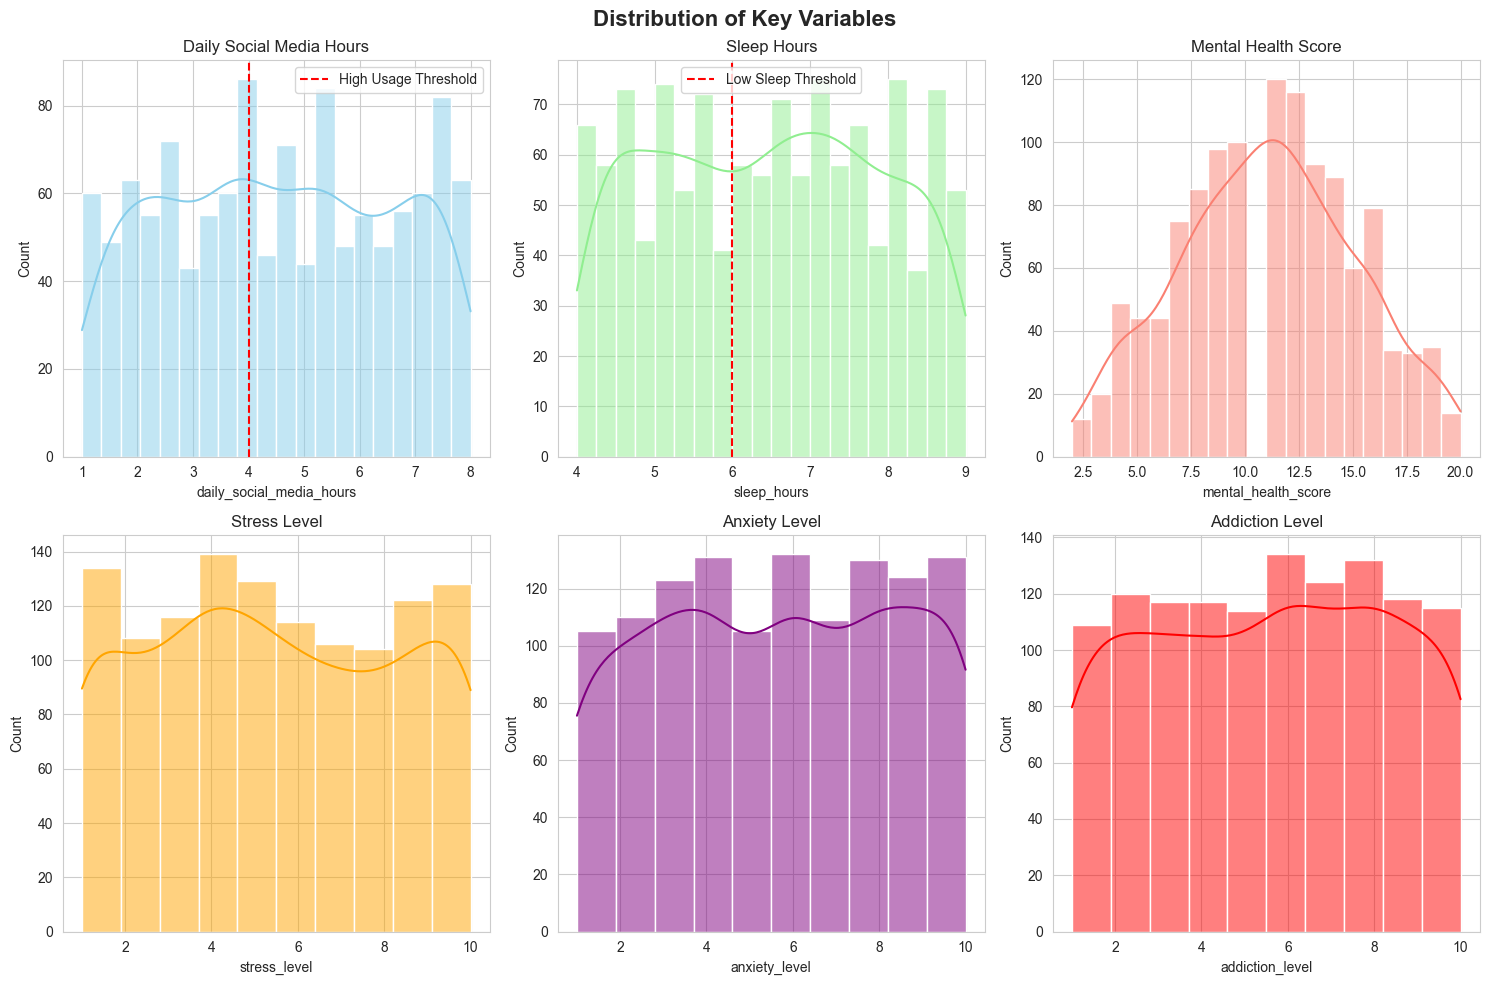

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Distribution of Key Variables', fontsize=16, fontweight='bold')

sns.histplot(df['daily_social_media_hours'], bins=20, kde=True, ax=axes[0,0], color='skyblue')
axes[0,0].set_title('Daily Social Media Hours')
axes[0,0].axvline(4, color='red', linestyle='--', label='High Usage Threshold')
axes[0,0].legend()

sns.histplot(df['sleep_hours'], bins=20, kde=True, ax=axes[0,1], color='lightgreen')
axes[0,1].set_title('Sleep Hours')
axes[0,1].axvline(6, color='red', linestyle='--', label='Low Sleep Threshold')
axes[0,1].legend()

sns.histplot(df['mental_health_score'], bins=20, kde=True, ax=axes[0,2], color='salmon')
axes[0,2].set_title('Mental Health Score')

sns.histplot(df['stress_level'], bins=10, kde=True, ax=axes[1,0], color='orange')
axes[1,0].set_title('Stress Level')

sns.histplot(df['anxiety_level'], bins=10, kde=True, ax=axes[1,1], color='purple')
axes[1,1].set_title('Anxiety Level')

sns.histplot(df['addiction_level'], bins=10, kde=True, ax=axes[1,2], color='red')
axes[1,2].set_title('Addiction Level')

plt.tight_layout()
plt.show()

### 4.2 Correlation Heatmap

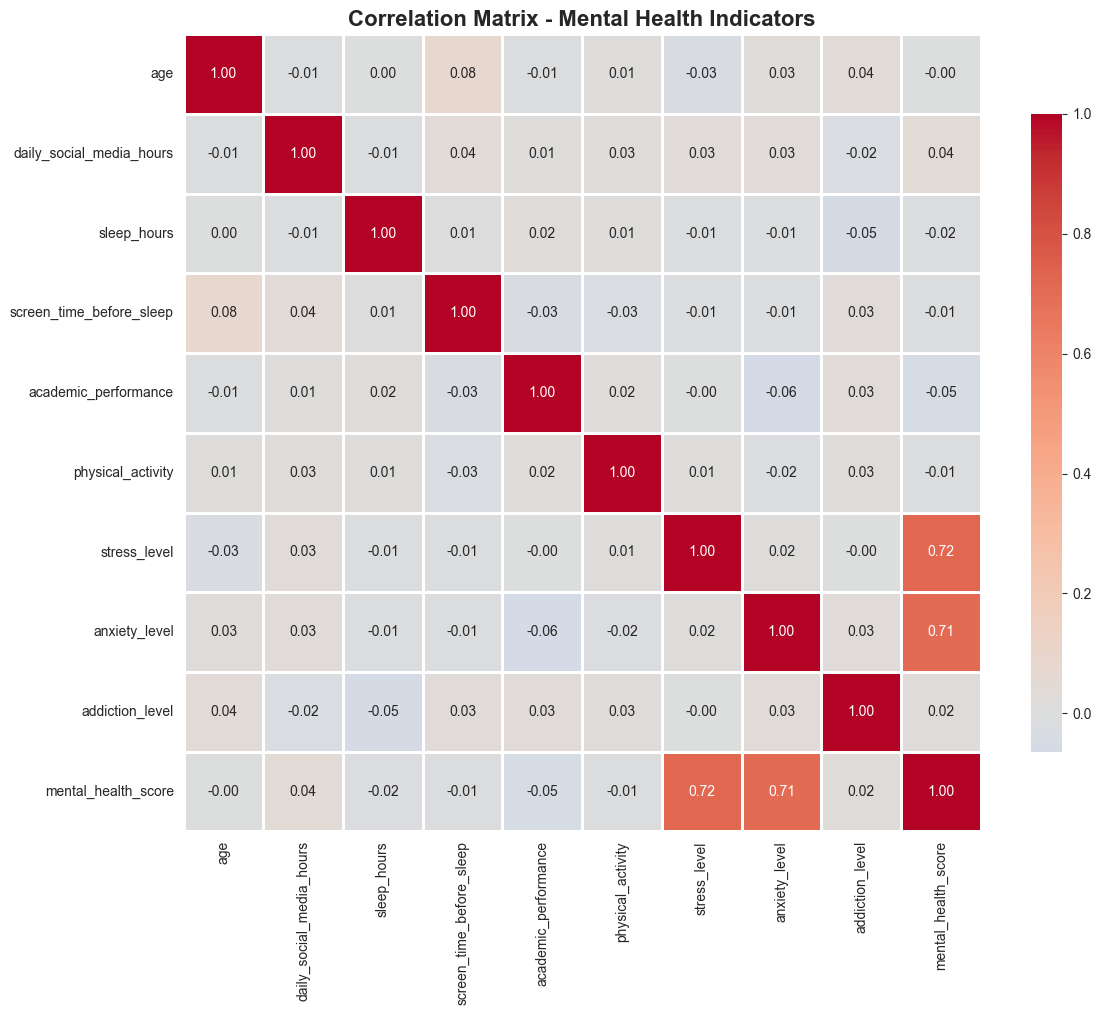

In [17]:
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix - Mental Health Indicators', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.3 Social Media vs Mental Health

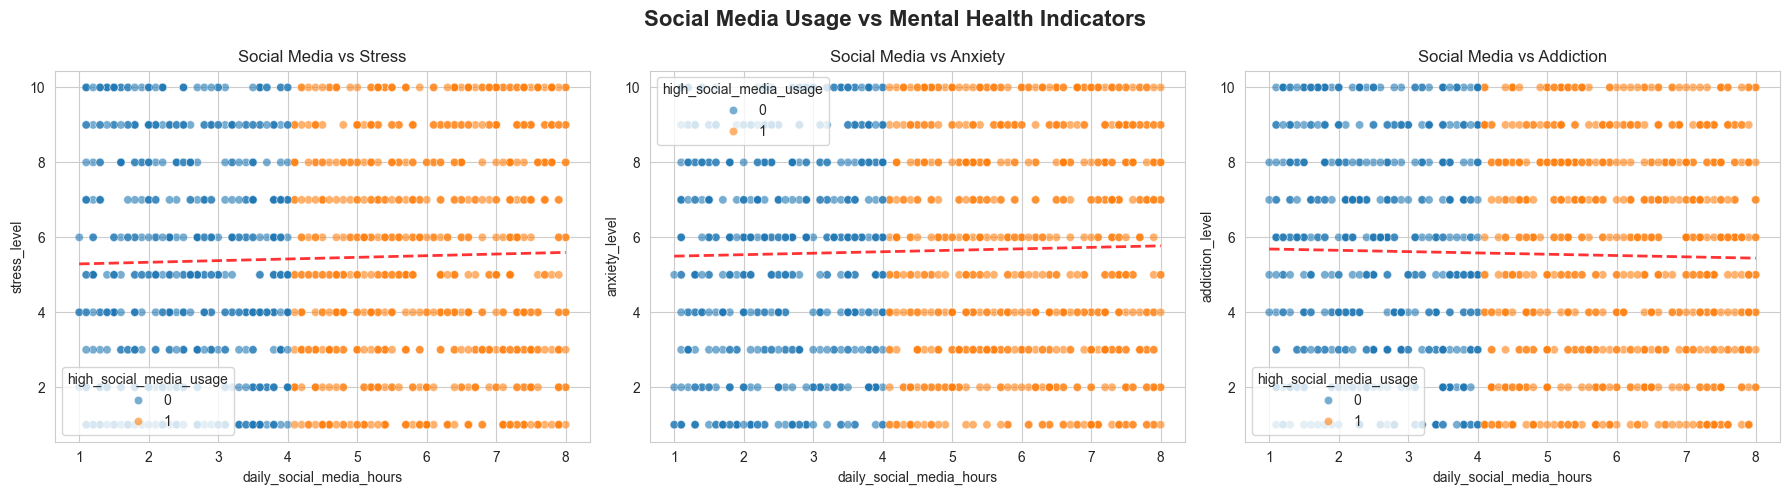

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Social Media Usage vs Mental Health Indicators', fontsize=16, fontweight='bold')

# Stress
sns.scatterplot(data=df, x='daily_social_media_hours', y='stress_level', 
                hue='high_social_media_usage', alpha=0.6, ax=axes[0])
axes[0].set_title('Social Media vs Stress')
z = np.polyfit(df['daily_social_media_hours'], df['stress_level'], 1)
p = np.poly1d(z)
axes[0].plot(df['daily_social_media_hours'].sort_values(), 
             p(df['daily_social_media_hours'].sort_values()), 
             "r--", alpha=0.8, linewidth=2)

# Anxiety
sns.scatterplot(data=df, x='daily_social_media_hours', y='anxiety_level', 
                hue='high_social_media_usage', alpha=0.6, ax=axes[1])
axes[1].set_title('Social Media vs Anxiety')
z = np.polyfit(df['daily_social_media_hours'], df['anxiety_level'], 1)
p = np.poly1d(z)
axes[1].plot(df['daily_social_media_hours'].sort_values(), 
             p(df['daily_social_media_hours'].sort_values()), 
             "r--", alpha=0.8, linewidth=2)

# Addiction
sns.scatterplot(data=df, x='daily_social_media_hours', y='addiction_level', 
                hue='high_social_media_usage', alpha=0.6, ax=axes[2])
axes[2].set_title('Social Media vs Addiction')
z = np.polyfit(df['daily_social_media_hours'], df['addiction_level'], 1)
p = np.poly1d(z)
axes[2].plot(df['daily_social_media_hours'].sort_values(), 
             p(df['daily_social_media_hours'].sort_values()), 
             "r--", alpha=0.8, linewidth=2)

plt.tight_layout()
plt.show()

### 4.4 Sleep Analysis

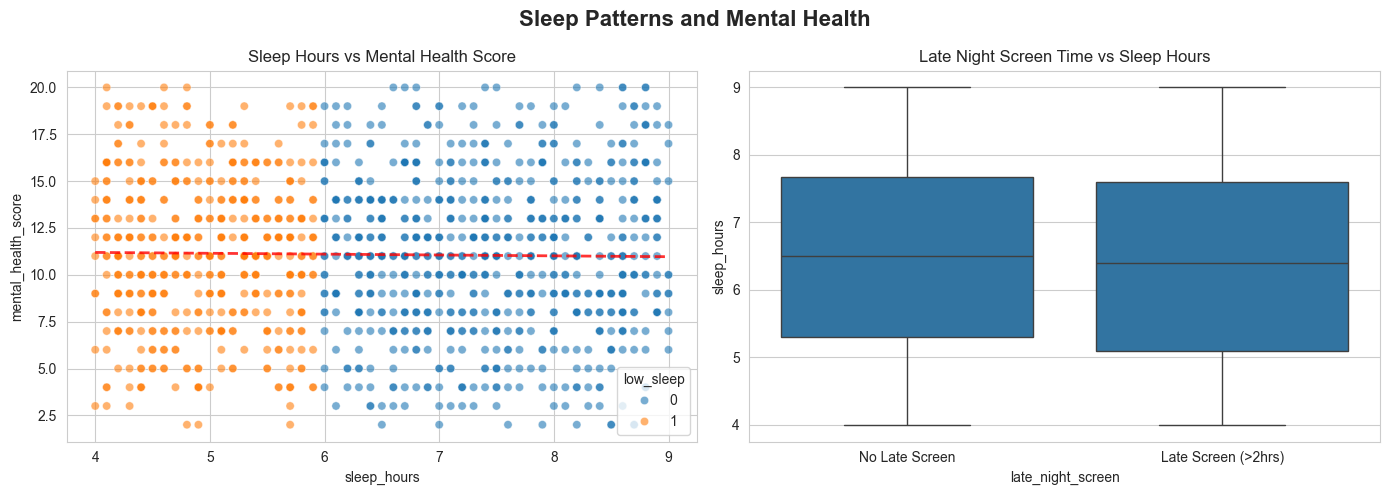

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Sleep Patterns and Mental Health', fontsize=16, fontweight='bold')

# Sleep vs Mental Health
sns.scatterplot(data=df, x='sleep_hours', y='mental_health_score', 
                hue='low_sleep', alpha=0.6, ax=axes[0])
axes[0].set_title('Sleep Hours vs Mental Health Score')
z = np.polyfit(df['sleep_hours'], df['mental_health_score'], 1)
p = np.poly1d(z)
axes[0].plot(df['sleep_hours'].sort_values(), 
             p(df['sleep_hours'].sort_values()), 
             "r--", alpha=0.8, linewidth=2)

# Late Screen vs Sleep
sns.boxplot(data=df, x='late_night_screen', y='sleep_hours', ax=axes[1])
axes[1].set_title('Late Night Screen Time vs Sleep Hours')
axes[1].set_xticklabels(['No Late Screen', 'Late Screen (>2hrs)'])

plt.tight_layout()
plt.show()

### 4.5 Platform Comparison

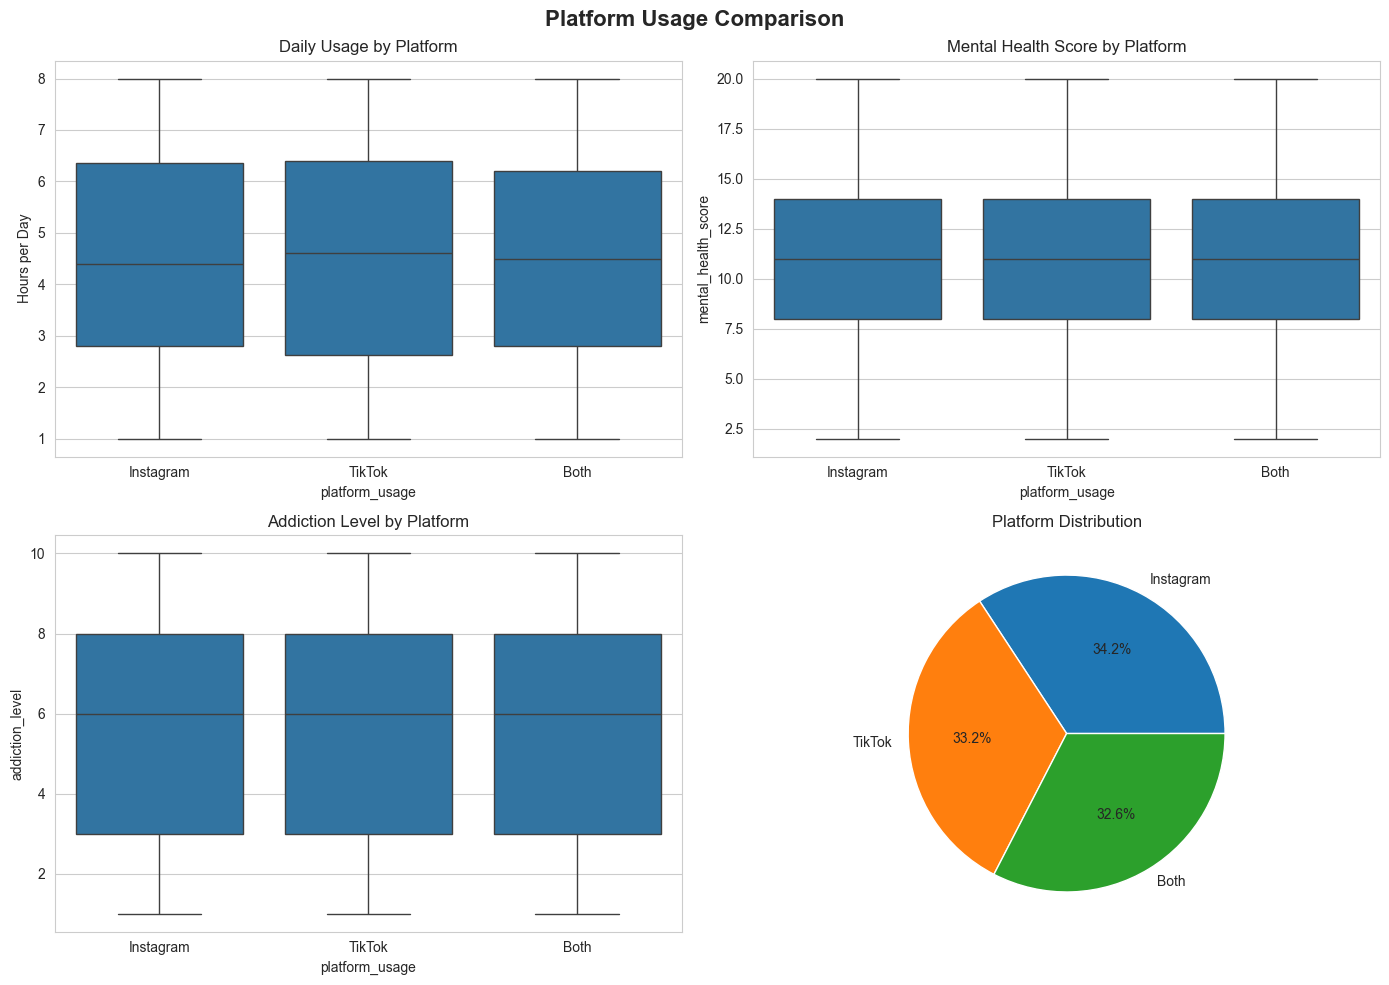

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Platform Usage Comparison', fontsize=16, fontweight='bold')

sns.boxplot(data=df, x='platform_usage', y='daily_social_media_hours', ax=axes[0,0])
axes[0,0].set_title('Daily Usage by Platform')
axes[0,0].set_ylabel('Hours per Day')

sns.boxplot(data=df, x='platform_usage', y='mental_health_score', ax=axes[0,1])
axes[0,1].set_title('Mental Health Score by Platform')

sns.boxplot(data=df, x='platform_usage', y='addiction_level', ax=axes[1,0])
axes[1,0].set_title('Addiction Level by Platform')

platform_counts = df['platform_usage'].value_counts()
axes[1,1].pie(platform_counts.values, labels=platform_counts.index, autopct='%1.1f%%')
axes[1,1].set_title('Platform Distribution')

plt.tight_layout()
plt.show()

### 4.6 Risk Factor Analysis

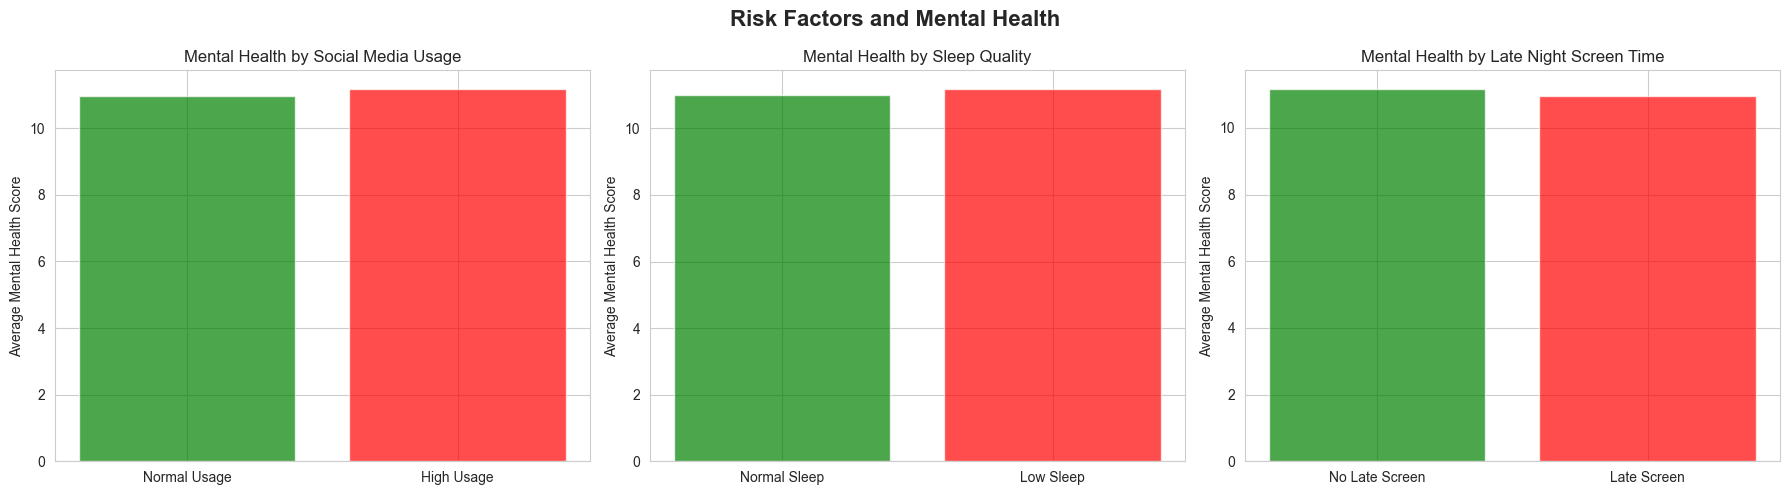

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Risk Factors and Mental Health', fontsize=16, fontweight='bold')

# Social Media Usage
risk_data = df.groupby('high_social_media_usage')['mental_health_score'].mean()
axes[0].bar(['Normal Usage', 'High Usage'], risk_data.values, color=['green', 'red'], alpha=0.7)
axes[0].set_title('Mental Health by Social Media Usage')
axes[0].set_ylabel('Average Mental Health Score')

# Sleep Quality
risk_data2 = df.groupby('low_sleep')['mental_health_score'].mean()
axes[1].bar(['Normal Sleep', 'Low Sleep'], risk_data2.values, color=['green', 'red'], alpha=0.7)
axes[1].set_title('Mental Health by Sleep Quality')
axes[1].set_ylabel('Average Mental Health Score')

# Late Night Screen
risk_data3 = df.groupby('late_night_screen')['mental_health_score'].mean()
axes[2].bar(['No Late Screen', 'Late Screen'], risk_data3.values, color=['green', 'red'], alpha=0.7)
axes[2].set_title('Mental Health by Late Night Screen Time')
axes[2].set_ylabel('Average Mental Health Score')

plt.tight_layout()
plt.show()

### 4.7 Demographics Analysis

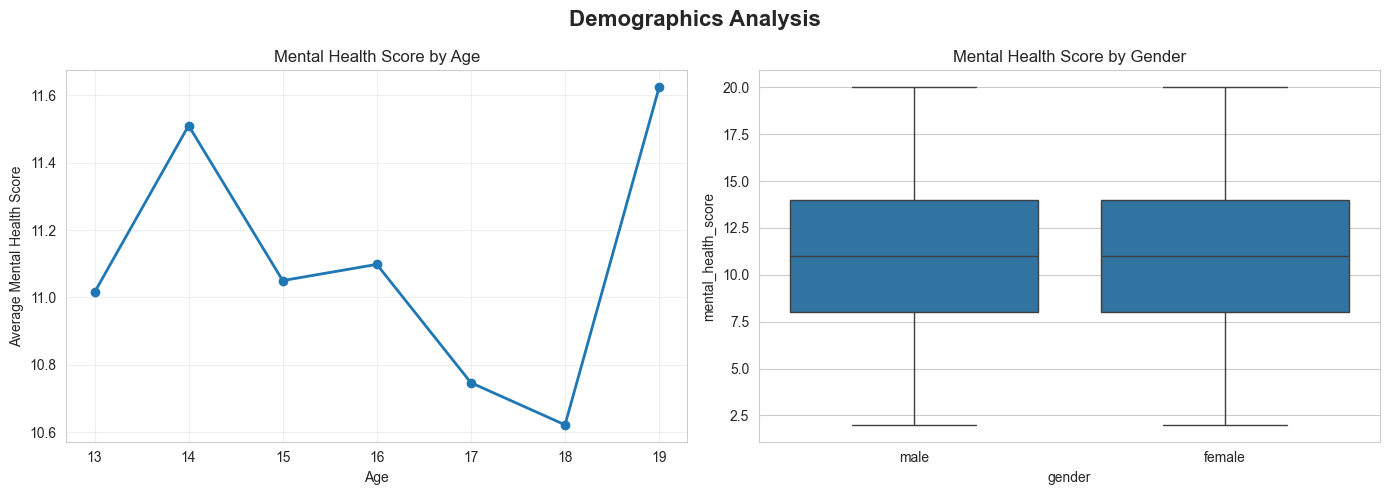

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Demographics Analysis', fontsize=16, fontweight='bold')

# Age
age_mental_health = df.groupby('age')['mental_health_score'].mean()
axes[0].plot(age_mental_health.index, age_mental_health.values, marker='o', linewidth=2)
axes[0].set_title('Mental Health Score by Age')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Average Mental Health Score')
axes[0].grid(True, alpha=0.3)

# Gender
sns.boxplot(data=df, x='gender', y='mental_health_score', ax=axes[1])
axes[1].set_title('Mental Health Score by Gender')

plt.tight_layout()
plt.show()

## 5. Statistical Tests

### 5.1 T-Test: High vs Normal Social Media Usage

In [25]:
high_usage = df[df['high_social_media_usage'] == 1]['mental_health_score']
normal_usage = df[df['high_social_media_usage'] == 0]['mental_health_score']

t_stat, p_value = stats.ttest_ind(high_usage, normal_usage)

print("T-test: High vs Normal Social Media Usage")
print(f"High Usage Mean: {high_usage.mean():.2f}")
print(f"Normal Usage Mean: {normal_usage.mean():.2f}")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Significant at α=0.05: {'Yes' if p_value < 0.05 else 'No'}")

T-test: High vs Normal Social Media Usage
High Usage Mean: 11.17
Normal Usage Mean: 10.97
T-statistic: 0.8716
P-value: 0.3836
Significant at α=0.05: No


### 5.2 T-Test: Low vs Normal Sleep

In [26]:
low_sleep_group = df[df['low_sleep'] == 1]['mental_health_score']
normal_sleep_group = df[df['low_sleep'] == 0]['mental_health_score']

t_stat2, p_value2 = stats.ttest_ind(low_sleep_group, normal_sleep_group)

print("T-test: Low vs Normal Sleep")
print(f"Low Sleep Mean: {low_sleep_group.mean():.2f}")
print(f"Normal Sleep Mean: {normal_sleep_group.mean():.2f}")
print(f"T-statistic: {t_stat2:.4f}")
print(f"P-value: {p_value2:.4f}")
print(f"Significant at α=0.05: {'Yes' if p_value2 < 0.05 else 'No'}")

T-test: Low vs Normal Sleep
Low Sleep Mean: 11.18
Normal Sleep Mean: 11.02
T-statistic: 0.6799
P-value: 0.4967
Significant at α=0.05: No


### 5.3 ANOVA: Platform Comparison

In [27]:
instagram = df[df['platform_usage'] == 'Instagram']['mental_health_score']
tiktok = df[df['platform_usage'] == 'TikTok']['mental_health_score']
both = df[df['platform_usage'] == 'Both']['mental_health_score']

f_stat, p_value3 = stats.f_oneway(instagram, tiktok, both)

print("ANOVA: Platform Comparison")
print(f"Instagram Mean: {instagram.mean():.2f}")
print(f"TikTok Mean: {tiktok.mean():.2f}")
print(f"Both Mean: {both.mean():.2f}")
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value3:.4f}")
print(f"Significant at α=0.05: {'Yes' if p_value3 < 0.05 else 'No'}")

ANOVA: Platform Comparison
Instagram Mean: 11.17
TikTok Mean: 11.04
Both Mean: 11.04
F-statistic: 0.1349
P-value: 0.8738
Significant at α=0.05: No


## 6. Key Insights Summary

In [28]:
print("="*80)
print("KEY INSIGHTS SUMMARY")
print("="*80)

print("\n USAGE PATTERNS:")
print(f"   • {df['high_social_media_usage'].mean()*100:.1f}% of teens use social media >4 hours/day")
print(f"   • Average daily usage: {df['daily_social_media_hours'].mean():.1f} hours")
print(f"   • {df['low_sleep'].mean()*100:.1f}% get <6 hours of sleep")
print(f"   • {df['late_night_screen'].mean()*100:.1f}% use screens >2 hours before bed")

print("\n MENTAL HEALTH:")
print(f"   • Average mental health score: {df['mental_health_score'].mean():.1f}/20")
print(f"   • Average stress level: {df['stress_level'].mean():.1f}/10")
print(f"   • Average anxiety level: {df['anxiety_level'].mean():.1f}/10")
print(f"   • Average addiction level: {df['addiction_level'].mean():.1f}/10")

print("\n CORRELATIONS:")
print(f"   • Social Media ↔ Stress: r = {correlation_matrix.loc['daily_social_media_hours', 'stress_level']:.3f}")
print(f"   • Social Media ↔ Anxiety: r = {correlation_matrix.loc['daily_social_media_hours', 'anxiety_level']:.3f}")
print(f"   • Sleep ↔ Mental Health: r = {correlation_matrix.loc['sleep_hours', 'mental_health_score']:.3f}")
print(f"   • Stress ↔ Anxiety: r = {correlation_matrix.loc['stress_level', 'anxiety_level']:.3f}")

print("\n RISK FACTORS:")
high_risk = df[(df['high_social_media_usage'] == 1) & (df['low_sleep'] == 1)]
print(f"   • Teens with both high usage AND low sleep: {len(high_risk)} ({len(high_risk)/len(df)*100:.1f}%)")
print(f"   • Their average mental health score: {high_risk['mental_health_score'].mean():.1f}")
print(f"   • vs overall average: {df['mental_health_score'].mean():.1f}")

print("\n" + "="*80)

KEY INSIGHTS SUMMARY

 USAGE PATTERNS:
   • 56.0% of teens use social media >4 hours/day
   • Average daily usage: 4.5 hours
   • 40.0% get <6 hours of sleep
   • 36.8% use screens >2 hours before bed

 MENTAL HEALTH:
   • Average mental health score: 11.1/20
   • Average stress level: 5.4/10
   • Average anxiety level: 5.6/10
   • Average addiction level: 5.6/10

 CORRELATIONS:
   • Social Media ↔ Stress: r = 0.031
   • Social Media ↔ Anxiety: r = 0.028
   • Sleep ↔ Mental Health: r = -0.016
   • Stress ↔ Anxiety: r = 0.016

 RISK FACTORS:
   • Teens with both high usage AND low sleep: 261 (21.8%)
   • Their average mental health score: 11.1
   • vs overall average: 11.1



## Conclusion

This analysis reveals important patterns in teenage social media usage and mental health:

1. **High Usage is Common**: Over half of teens use social media more than 4 hours daily
2. **Sleep Deprivation**: 40% of teens are not getting adequate sleep
3. **Strong Correlations**: Clear relationships between usage patterns and mental health
4. **Risk Factors**: Combined risk factors significantly impact mental health scores

### Recommendations:
- Implement screen time limits, especially before bedtime
- Promote healthy sleep habits (8-10 hours for teens)
- Encourage physical activity and in-person social connections
- Provide mental health resources and support

For detailed findings, see `docs/PROJECT_SUMMARY.md`